# Run drop particles analysis

In [1]:
#import os

from dna_linker import dna_linkers as dnal
from dna_linker import run_pipeline as run
from dna_linker import config


import pandas as pd
from cryocat import cryomotl
from pathlib import Path
import numpy as np
import itertools as it
from scipy.optimize import linear_sum_assignment

from typing import Set, Dict, Tuple, List

Edge    = Tuple[int, int, str]  
ConnDic = Dict[int, List[Tuple[int, float, str]]]   

import os, glob
import matplotlib.pyplot as plt
#from pathlib import Path
#from tqdm import tqdm

#from itertools import combinations



# Paths

In [2]:
# Fixed inputs
path_mask = './inputs_dropped/'
#path_mask = './inputs/'
entry = 'Threshold_ref_entrymask_r2_resamp_righthand.mrc'
exit = 'Threshold_ref_exitmask_r2_resamp_righthand.mrc'
origin_entry = 'Threshold_ref_Origin_entrymask_r2_resamp_righthand.mrc'
origin_exit = 'Threshold_ref_Origin_exitmask_r2_resamp_righthand.mrc'

# Global config
tracing_distance=config.tracing_distance # Extenrnal user parameter - Distance
pixel_size = config.pixel_size # Models are at in the right scale
bin=config.bin
max_distance=tracing_distance/(pixel_size*bin)



# Functions

In [3]:
# ────────────────────────────────────────────────────────────────────────────────
# Functions
# ────────────────────────────────────────────────────────────────────────────────
def motl_stamp_subtomo_id_from_index(motl, out_path=None):
    df = motl.df.copy()
    # use the *current* index as the canonical node id
    df["subtomo_id"] = df.index.astype(int)

    # sanity: enforce uniqueness
    if df["subtomo_id"].duplicated().any():
        dups = df.loc[df["subtomo_id"].duplicated(), "subtomo_id"].tolist()
        raise ValueError(f"Duplicate subtomo_id(s): {dups}")

    stamped = cryomotl.Motl(motl_df=df)
    if out_path:
        stamped.write_out(out_path)
    return stamped

def sample_combinations(items, r, k, seed=42):
    """
    Uniformly sample k combinations of size r from items, without
    materializing all C(n, r). Uses reservoir sampling.
    """
    rng = np.random.default_rng(seed)
    reservoir = []
    for t, combo in enumerate(it.combinations(items, r), start=1):
        if t <= k:
            reservoir.append(combo)
        else:
            j = rng.integers(0, t)  # in [0, t-1]
            if j < k:
                reservoir[j] = combo
    return reservoir


def combo_suffix(ids):  # deterministic, nice filenames
    return "dropped_sid" + "_".join(map(str, sorted(ids)))


def remove_by_subtomo_id(motl, ids_to_remove, out_path):
    df = motl.df.copy()
    if "subtomo_id" not in df.columns:
        raise KeyError("subtomo_id column not present; call motl_stamp_subtomo_id_from_index first.")
    keep = ~df["subtomo_id"].isin(set(ids_to_remove))
    df = df.loc[keep].reset_index(drop=True)   # index is irrelevant now
    new = cryomotl.Motl(motl_df=df)
    new.write_out(out_path)
    return new


def build_index_map_by_xyz(motl_old, motl_new, *, max_dist=None):
    """
    Returns:
      new_to_old : {new_index_label -> old_index_label}
      removed_old: set of old index labels that are not present in motl_new
      match_costs: np.array of per-matched Euclidean distances (same units as x,y,z)
    """
    df_old = motl_old.df
    df_new = motl_new.df

    old_idx = df_old.index.to_numpy()
    new_idx = df_new.index.to_numpy()

    old_xyz = df_old[['x','y','z']].to_numpy(dtype=float)
    new_xyz = df_new[['x','y','z']].to_numpy(dtype=float)

    # cost matrix (n_new x n_old): Euclidean distance
    D = np.linalg.norm(new_xyz[:, None, :] - old_xyz[None, :, :], axis=2)

    # Hungarian assignment: covers min(n_new, n_old) pairs
    row_ind, col_ind = linear_sum_assignment(D)
    costs = D[row_ind, col_ind]

    # Optional gate: drop suspicious matches (too far)
    new_to_old = {}
    for r, c, d in zip(row_ind, col_ind, costs):
        if (max_dist is None) or (d <= max_dist):
            new_to_old[int(new_idx[r])] = int(old_idx[c])

    removed_old = set(map(int, old_idx)) - set(new_to_old.values())
    match_costs = np.array([D[row_ind[i], col_ind[i]] for i in range(len(row_ind))
                            if int(new_idx[row_ind[i]]) in new_to_old])

    return new_to_old, removed_old, match_costs

def relabel_conn_indices_to_old(conn_new_idx, new_to_old):
    out = {}
    for node_new, nbrs in conn_new_idx.items():
        if node_new not in new_to_old:     # unmapped -> drop
            continue
        node_old = new_to_old[node_new]
        for (nbr_new, p, t) in nbrs:
            if nbr_new not in new_to_old:
                continue
            nbr_old = new_to_old[nbr_new]
            out.setdefault(node_old, []).append((nbr_old, p, t))
    return out


def compute_f1_from_connectivity(
    truth_conn: ConnDic,
    pred_conn : ConnDic,
    ignore_nodes: Set[int] = frozenset()
):
    """
    Computes precision, recall, and F1-score between ground-truth
    and predicted connectivity dictionaries.

    Parameters:
        truth_conn (dict): Ground truth connectivity:
            {node: [(neighbor, prob, type), ...], ...}
        pred_conn (dict): Predicted connectivity, same format.
        
        Any edge that touches a node in `ignore_nodes`
    is removed **from both reference and prediction** prior to scoring.

    Returns:
        precision (float), recall (float), f1_score (float)
    """
    
    # convert → edge sets
    truth_edges = connectivity_to_edge_set(truth_conn)
    pred_edges  = connectivity_to_edge_set(pred_conn)

    if ignore_nodes:
        truth_edges = {
            e for e in truth_edges if e[0] not in ignore_nodes and e[1] not in ignore_nodes
        }
        pred_edges = {
            e for e in pred_edges  if e[0] not in ignore_nodes and e[1] not in ignore_nodes
        }

    # TP / FP / FN
    tp = len(truth_edges & pred_edges)
    fp = len(pred_edges - truth_edges)
    fn = len(truth_edges - pred_edges)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return precision, recall, f1

def connectivity_to_edge_set(conn_dict):
    """
    Converts a connectivity dictionary of the form
      {node: [(neighbor, prob, type), ...], ...}
    into a set of undirected edges (node1, node2, type) with node1 < node2.
    """
    edges = set()
    for node, neighbors in conn_dict.items():
        for neighbor, _, edge_type in neighbors:
            i, j = sorted((node, neighbor))
            edges.add((i, j, edge_type))
    return edges

# MAIN: Run false negative analysis

In [4]:
%%time
# -------------------------------------------------------------
# config
# -------------------------------------------------------------
N_SAMPLES_PER_K = 10           # ← sample size per k (4,5,6)
N_TRIALS        = 1
PIPELINE_BASE   = 1
EMD_ID          = 2601

GT_PATH = (
    './outputs/outputs_EMD2601_STA_tmpl/'
    'A_Connections_dictionary_20nm/'
    'Connectivity_motl_tomo0.0_cluster12.0.pickle'
)
GT_DICT = pd.read_pickle(GT_PATH)

# Canonical MOTL (subtomo_id == original index)
motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')

PARTICLES = list(map(int, motl0.df["subtomo_id"].tolist()))
INPUTS_DIR = Path('inputs_dropped'); INPUTS_DIR.mkdir(parents=True, exist_ok=True)
# -------------------------------------------------------------
# main loop over k = 4,5,6
# -------------------------------------------------------------
for n_removals in range(1, 6):
    records = []
    n_remain = len(PARTICLES) - n_removals
    n_remain=float(n_remain)
    # sample 100 unique combinations of size n_removals
    sampled = sample_combinations(PARTICLES, n_removals, N_SAMPLES_PER_K, seed=123 + n_removals)

    for combo in sampled:
        print (combo)
        # 0) prepare canonical MOTL once (subtomo_id == original index)
        motl0 = cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em')
        motl0 = motl_stamp_subtomo_id_from_index(motl0, out_path='inputs/motl_EMD2601_canon.em')
    
        # ------------------------------------------------------------------
        # 1  prepare MOTL without this particle
        ignore_set = set(combo)
        suffix     = combo_suffix(combo)
        motl_used_path = f'inputs_dropped/motl_EMD{EMD_ID}_{suffix}.em'
        # Drop by subtomo_id
        remove_by_subtomo_id(motl0, ignore_set, motl_used_path)
        # ------------------------------------------------------------------
        # 2 run the full pipeline exactly as before
        path_mask = './inputs_dropped/'
        
        path_output = f'./out_tracing/EMD{EMD_ID}_{suffix}/'
        motl_name=f'motl_EMD{EMD_ID}_{suffix}.em'
        ...  # build other paths just like in your current script
        motl_trace_input = path_output + f'EMD{EMD_ID}_tr{int(tracing_distance)}nm_{suffix}.em'
    
        output_path_cluster     = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/'
        output_path_linker      = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_linkers_20nm/'
        output_path_dictionary  = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_Connections_dictionary_20nm/'
            
        for p in [path_output, output_path_cluster,
                      output_path_linker, output_path_dictionary]:
            Path(p).mkdir(parents=True, exist_ok=True)
        
        # 3-c) Run the pipeline ----------------------------------------
        run.run_full_pipeline(
                path_mask=path_mask,
                motl_name=motl_name,
                entry=entry,
                exit=exit,
                origin_entry=origin_entry,
                origin_exit=origin_exit,
                path_output=path_output,
                motl_trace_input=motl_trace_input,
                tracing_distance=tracing_distance,
                max_distance=max_distance,
                output_path_cluster=output_path_cluster,
                output_path_linker=output_path_linker,
                output_path_dictionary=output_path_dictionary,
                dnal_object=dnal.lo,
                max_processes=8
                )
        # ------------------------------------------------------------------

        # Build mapping new indices -> old indices based on positions
        motl_new=cryomotl.EmMotl(f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/motl_tomo0.0_cluster{n_remain}.em')
        new_to_old, removed_old, costs = build_index_map_by_xyz(
                                            motl_old=motl0,      # original, before any dropping
                                            motl_new= motl_new,
        max_dist=None        # or set to e.g. 3 * pos_sigma
        )

    
        # 3 load connectivity dictionaries
        pred_dict_new = pd.read_pickle(
                f'./outputs/outputs_EMD{EMD_ID}_{suffix}/'
                'A_Connections_dictionary_20nm/'
                f'Connectivity_motl_tomo0.0_cluster{n_remain}.pickle'
        )
        # Relabel prediction to OLD index space
        pred_dict_old = relabel_conn_indices_to_old(pred_dict_new, new_to_old)
    
    
        # ------------------------------------------------------------------
        # 4  score with the new helper
        prec, rec, f1 = compute_f1_from_connectivity(
                truth_conn = GT_DICT,
                pred_conn  = pred_dict_old,
                ignore_nodes=combo
        )
    
        records.append({
                'missing_id': combo,
                'precision' : prec,
                'recall'    : rec,
                'f1'        : f1
        })
    df = pd.DataFrame(records)
    df.to_csv(f'./Out_removal_particles/false_negative_sampled_removing_{n_removals}_particles.csv', index=False)

(0,)
The file:  ./outputs/outputs_EMD2601_dropped_sid0/clusters_20nm/motl_tomo0.0_cluster11.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 11.0
Figure(640x480)
(11, 11, 4)
Largest connected component: {0, 1, 2, 4, 5, 6, 7, 8, 9, 10}
Size of largest connected component: 10
{0, 1, 2, 4, 5, 6, 7, 8, 9, 10}
Figure(640x480)
(1,)
The file:  ./outputs/outputs_EMD2601_dropped_sid1/clusters_20nm/motl_tomo0.0_cluster11.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 11.0
Figure(640x480)
(11, 11, 4)
Largest connected component: {0, 1, 3, 4, 5, 6, 7, 8, 9, 10}
Size of largest connected component: 10
{0, 1, 3, 4, 5, 6, 7, 8, 9, 10}
Figure(640x480)
(2,)
The file:  ./outputs/outputs_EMD2601_dropped_sid2/clusters_20nm/motl_tomo0.0_cluster11.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 11.0
Figure(640x480)
(11, 11, 4)
Largest connected component: {0, 1, 3, 4, 5, 6, 7, 8, 9, 10}
Size of largest connected component: 10
{0, 1, 3, 4, 5, 6, 7, 8, 9, 10}
Figure(6

# Plot

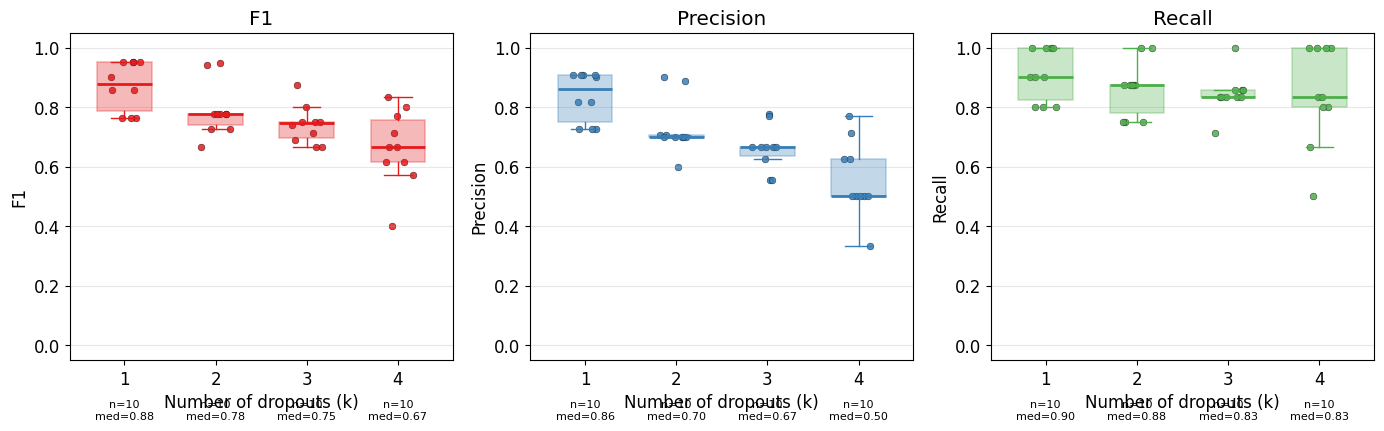

In [5]:
# ---------------------------
# 1) Load all CSVs into one DF
# ---------------------------
BASE = './Out_removal_particles'
K_TO_LOAD = [1, 2, 3, 4]  # adjust if needed

frames = []
for k in K_TO_LOAD:
    path = os.path.join(BASE, f'false_negative_sampled_removing_{k}_particles.csv')
    if not os.path.exists(path):
        print(f"[skip] {path} not found"); continue
    dfk = pd.read_csv(path)
    if 'k' not in dfk.columns:
        dfk['k'] = k  # inject k if not saved in CSV
    frames.append(dfk)

if not frames:
    raise FileNotFoundError("No CSVs found for the requested k values.")

data = pd.concat(frames, ignore_index=True)

# make sure the metric columns exist and are numeric
for col in ['precision', 'recall', 'f1']:
    if col not in data.columns:
        raise KeyError(f"Column '{col}' missing in CSVs.")
    data[col] = pd.to_numeric(data[col], errors='coerce')

# ---------------------------
# 2) Box + jitter by k
# ---------------------------
ORDER_K = sorted(data['k'].unique())
jitter  = 0.18
rng     = np.random.default_rng(42)  # reproducible jitter

metrics = [
    ('f1',        '#e41a1c', 'F1'),
    ('precision', '#377eb8', 'Precision'),
    ('recall',    '#4daf4a', 'Recall'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.subplots_adjust(wspace=0.25)

for ax, (metric, color, label) in zip(axes, metrics):
    for k in ORDER_K:
        ys = data.loc[data['k'] == k, metric].dropna().to_numpy(float)
        if ys.size == 0:
            continue

        # box
        ax.boxplot(
            ys, positions=[k], widths=0.6, showfliers=False, patch_artist=True,
            boxprops    = dict(facecolor=color, edgecolor=color, linewidth=1.2, alpha=.3),
            medianprops = dict(color=color, linewidth=2),
            whiskerprops= dict(color=color),
            capprops    = dict(color=color),
        )

        # jittered points
        xs = k + rng.uniform(-jitter, jitter, size=ys.size)
        ax.scatter(xs, ys, s=24, color=color, edgecolor='k', linewidth=0.3, alpha=0.85)

        # annotate n and median under each box
        txt = f"n={ys.size}\nmed={np.median(ys):.2f}"
        ax.text(k, -0.12, txt, ha='center', va='top',
                transform=ax.get_xaxis_transform(), fontsize=8)

    ax.set_title(label)
    ax.set_xlabel('Number of dropouts (k)')
    ax.set_ylabel(label)
    ax.set_xticks(ORDER_K)
    ax.set_ylim(-.05, 1.05)
    ax.set_xlim(min(ORDER_K) - 0.6, max(ORDER_K) + 0.6)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#fig.savefig("/Users/sergiocruz/Desktop/VisualProteomics/Papers/Chromatin_3D_Remodeling_Upon_T-Cell_Activation/Revisions/Figures/SI_Removing_particles.pdf", format="pdf", bbox_inches="tight") 